# Mount Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from skimage.io import imread_collection
from matplotlib import pyplot
from matplotlib.image import imread
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sn

# Read train data

In [4]:
PATH = r'/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST'
files, dirs = 0, 0
for root, dirnames, filenames in os.walk(PATH):
    #print('Looking in:', root)
    dirs += len(dirnames)
    files += len(filenames)

print('Files: ', files)
print('Dictionaries: ', dirs)

Files:  4600
Dictionaries:  13


In [5]:
PATH = r'/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train'
files, dirs = 0, 0
for root, dirnames, filenames in os.walk(PATH):
    #print('Looking in:', root)
    dirs += len(dirnames)
    files += len(filenames)

print('Files: ', files)
print('Dictionaries: ', dirs)

Files:  3998
Dictionaries:  10


In [6]:
PATH = r'/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/test'
files, dirs = 0, 0
for root, dirnames, filenames in os.walk(PATH):
    #print('Looking in:', root)
    dirs += len(dirnames)
    files += len(filenames)

print('Files: ', files)
print('Dictionaries: ', dirs)

Files:  600
Dictionaries:  1


In [7]:
from skimage.io import imread_collection

#creating a collection with the available images
train0 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/0/*.jpg')
train1 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/1/*.jpg')
train2 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/2/*.jpg')
train3 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/3/*.jpg')
train4 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/4/*.jpg')
train5 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/5/*.jpg')
train6 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/6/*.jpg')
train7 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/7/*.jpg')
train8 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/8/*.jpg')
train9 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/9/*.jpg')

In [8]:
print(len(train0))
print(len(train1))
print(len(train2))
print(len(train3))
print(len(train4))
print(len(train5))
print(len(train6))
print(len(train7))
print(len(train8))
print(len(train9))

400
400
400
400
402
400
400
400
400
396


In [9]:
print(type(train0))
print(type(train1))
print(type(train2))
print(type(train3))
print(type(train4))
print(type(train5))
print(type(train6))
print(type(train7))
print(type(train8))
print(type(train9))

<class 'skimage.io.collection.ImageCollection'>
<class 'skimage.io.collection.ImageCollection'>
<class 'skimage.io.collection.ImageCollection'>
<class 'skimage.io.collection.ImageCollection'>
<class 'skimage.io.collection.ImageCollection'>
<class 'skimage.io.collection.ImageCollection'>
<class 'skimage.io.collection.ImageCollection'>
<class 'skimage.io.collection.ImageCollection'>
<class 'skimage.io.collection.ImageCollection'>
<class 'skimage.io.collection.ImageCollection'>


In [10]:
print(type(train0[0]))
print(type(train1[0]))
print(type(train2[0]))
print(type(train3[0]))
print(type(train4[0]))
print(type(train5[0]))
print(type(train6[0]))
print(type(train7[0]))
print(type(train8[0]))
print(type(train9[0]))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [11]:
print(np.shape(train0))

(400, 28, 28)


# Show some images as example - train data

# Read & Check test data

In [12]:
#creating a collection with the available images
test = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/test/test/*.jpg')
print(len(test))

600


In [13]:
print(type(test))
print(type(test[0]))
#print(np.shape(test))
print(np.shape(test[0]))

<class 'skimage.io.collection.ImageCollection'>
<class 'numpy.ndarray'>
(28, 28)


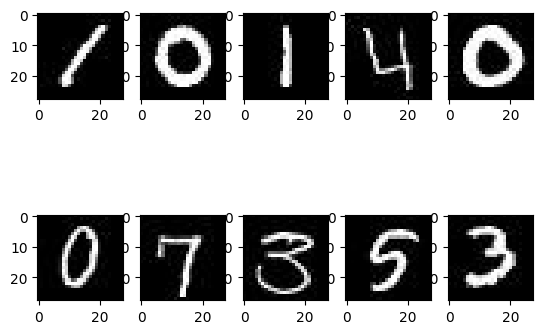

In [14]:
for i in range(10):
    pyplot.subplot(2, 5, i + 1)
    pyplot.imshow(test[i], cmap='gray')

In [15]:
test_labels = pd.read_csv('/content/drive/MyDrive/ML/computational data mining/TinyMNIST/test labels.csv')
test_labels

,id,category
0,0,1
1,1,0
2,2,1
3,3,4
4,4,0
...,...,...
595,653,8
596,654,7
597,659,6
598,672,8


# First Algorithm

##Vectorize test datas - first algorithm

In [16]:
test_list = []
for img in test:
  test_list.append(img.flatten())

print(len(test_list))
print(np.shape(test_list[0]))

600
(784,)


## calculate A0 to A9 for every classes - first algorithm

In [17]:
A = train0[0].flatten()

for img in train0[1:]:
  A = np.vstack((A, img.flatten()))

print(np.shape(A))

(400, 784)


In [18]:
def calculate_A(image_file):

  A = image_file[0].flatten()

  for img in image_file[1:]:
    A = np.vstack((A, img.flatten()))

  return A.T

train = [train0, train1, train2, train3, train4, train5, train6, train7, train8, train9]
A_list = []
for image_file in train:
  A = calculate_A(image_file)
  A_list.append(A)
  print(np.shape(A))

print('-'*20)
print(len(A_list))

(784, 400)
(784, 400)
(784, 400)
(784, 400)
(784, 402)
(784, 400)
(784, 400)
(784, 400)
(784, 400)
(784, 396)
--------------------
10


## QR Decomposition - first algorithm

In [19]:
# QR-Decomposition
def QR_decomposition(A):
  Q, R = np.linalg.qr(A)
  return Q, R

train = [train0, train1, train2, train3, train4, train5, train6, train7, train8, train9]

Q_list = []
for image_file in train:
  A = calculate_A(image_file)
  QR = QR_decomposition(A)
  Q_list.append(QR[0])
print('len of Q_list: ', len(Q_list))
print(np.shape(Q_list[0]))

len of Q_list:  10
(784, 400)


In [20]:
# X_hat = Q(Q.T.x)
def solve_x_hat(x_test, Q):
  x_hat = Q.dot((Q.T).dot(x_test))
  return x_hat

x_hat_list = []
for img in test_list:
  x_hat = []
  for q in Q_list:
    x_hat.append(solve_x_hat(img, q))
  x_hat_list.append(x_hat)

print(len(x_hat_list))
print(np.shape(x_hat_list[0]))


600
(10, 784)


## Predict label for test datas - first algorithm

In [21]:
# e = ||X - X_hat||
def predict(x_test, x_hat):
  return np.linalg.norm(x_test - x_hat)

predicted_list = []
for i in range(len(test_list)):
  pred_list = []
  x_hat = x_hat_list[i]
  for x in x_hat:
    pred_list.append(predict(test_list[i], x))
  predicted_list.append(np.argmin(pred_list))

print(len(predicted_list))
print(predicted_list[0])



600
1


## Calculate Accuracy & Confusion matrix - first algorithm

In [22]:
correct_pred = 0

y_test = test_labels['category']
y_pred = predicted_list

for i in range(len(y_test)):
  if y_pred[i] == y_test[i]:
    correct_pred = correct_pred + 1
  else:
    correct_pred = correct_pred

score = correct_pred / len(y_test)
print('Accuracy of prediction is: ', score)

Accuracy of prediction is:  0.8233333333333334


In [23]:
conf_matrix = confusion_matrix(y_test, predicted_list)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[56  0  0  0  0  1  2  0  1  0]
 [ 0 56  1  0  0  0  1  0  2  0]
 [ 0  1 51  2  1  0  2  0  3  0]
 [ 0  1  2 47  0  1  1  1  6  1]
 [ 0  0  1  1 45  0  0  2  4  7]
 [ 2  0  2  4  0 36  5  0 11  0]
 [ 0  1  1  0  0  1 57  0  0  0]
 [ 0  1  0  0  2  0  0 46  1 10]
 [ 0  6  0  3  0  1  2  0 46  2]
 [ 1  0  0  1  3  0  0  0  1 54]]


In [24]:
class_report = classification_report(y_test, predicted_list)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        60
           1       0.85      0.93      0.89        60
           2       0.88      0.85      0.86        60
           3       0.81      0.78      0.80        60
           4       0.88      0.75      0.81        60
           5       0.90      0.60      0.72        60
           6       0.81      0.95      0.88        60
           7       0.94      0.77      0.84        60
           8       0.61      0.77      0.68        60
           9       0.73      0.90      0.81        60

    accuracy                           0.82       600
   macro avg       0.84      0.82      0.82       600
weighted avg       0.84      0.82      0.82       600



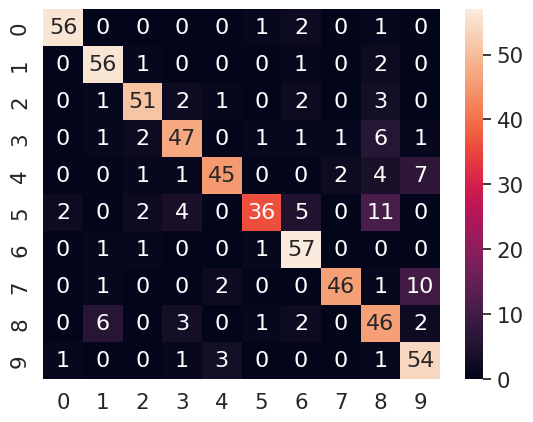

In [25]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt


df_cm = pd.DataFrame(conf_matrix, range(10), range(10))
sn.set(font_scale=1.4) # for label size
sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}) # font size

plt.show()


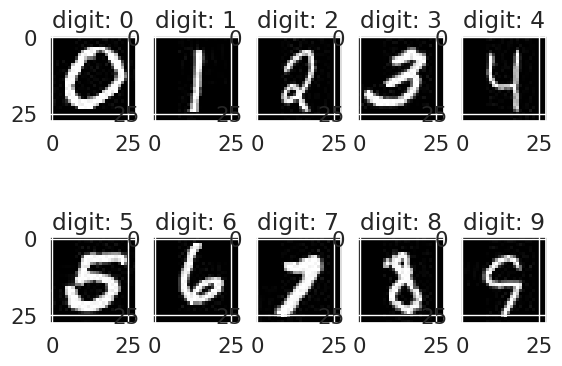

In [26]:
from matplotlib import pyplot
from matplotlib.image import imread

train = [train0, train1, train2, train3, train4, train5, train6, train7, train8, train9]    #folder where your photos are store

for i in range(len(train)):
    pyplot.subplot(2, 5, i + 1)
    x= train[i]
    pyplot.imshow(x[i], cmap='gray')
    plt.title(f"digit: {i}")


# Second Algorithm- Least Square

## vectorize test data - second algorithm

In [27]:
A_test = test[0].flatten()

for img in test[1:]:
  A_test = np.vstack((A_test, img.flatten()))

print(np.shape(A_test))

(600, 784)


## calculate A0 to A9 for every classes - second algorithm

In [28]:
def calculate_A(image_file):

  A = image_file[0].flatten()

  for img in image_file[1:]:
    A = np.vstack((A, img.flatten()))
  return A

train = [train0, train1, train2, train3, train4, train5, train6, train7, train8, train9]
A_list = []
for image_file in train:
  A = calculate_A(image_file)
  A_list.append(A)
  print(np.shape(A))

print('-'*20)
print(len(A_list))

(400, 784)
(400, 784)
(400, 784)
(400, 784)
(402, 784)
(400, 784)
(400, 784)
(400, 784)
(400, 784)
(396, 784)
--------------------
10


## QR Decomposition - second algorithm

In [29]:
# QR - Decompositin
def QR_decomposition(A):
  Q, R = np.linalg.qr(A)
  return Q, R

train = [train0, train1, train2, train3, train4, train5, train6, train7, train8, train9]

Q_list = []
R_list = []
for image_file in train:
  A = calculate_A(image_file)
  QR = QR_decomposition(A)
  Q_list.append(QR[0])
  R_list.append(QR[1])
print('len of Q_list: ', len(Q_list))
print(np.shape(Q_list[0]))
print('len of R_list: ', len(R_list))
print(np.shape(R_list[0]))

len of Q_list:  10
(400, 400)
len of R_list:  10
(400, 784)


In [30]:
# X = R+ Q.T A
def solve_x(Q, R, A):
  x = np.linalg.pinv(R).dot(Q.T).dot(A)
  return x


x_list = []
for i in range(len(A_list)):
  x = solve_x(Q_list[i], R_list[i], A_list[i])
  x_list.append(x)

print('-'*20)
print(len(x_list))
print(np.shape(x_list[0]))


--------------------
10
(784, 784)


In [31]:
# A_hat = A_test.X
def calculate_A_hat(A_test, x):
  A_hat = A_test.dot(x.T)
  return A_hat

A_hat_list = []
for i in range(len(x_list)):
  A_hat = calculate_A_hat(A_test, x_list[i])
  A_hat_list.append(A_hat)

print(len(A_hat_list))
print(np.shape(A_hat_list[0]))

10
(600, 784)


In [32]:
# e = ||A - A_hat||
def predict(A_test, A_hat):
  return np.linalg.norm(A_test - A_hat)


predicted_list = []
for i in range(600):
  error = []
  for A_hat in A_hat_list:
    error.append(predict(A_test[i], A_hat[i]))
  predicted_list.append(np.argmin(error))

print(len(predicted_list))
print(predicted_list[0])

600
1


## Calculate Accuracy & Confusion matrix - second algorithm

In [33]:
import numpy as np
from sklearn.metrics import accuracy_score

print(accuracy_score(test_labels['category'], predicted_list))


0.8233333333333334
